In [126]:
#사용하는 폴더를 위한 변수를 설정
ROOT_FOLDER = '/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras'

In [127]:
!mkdir $ROOT_FOLDER
!mkdir $ROOT_FOLDER/FIREdevkit
!mkdir $ROOT_FOLDER/FIREdevkit/Annotations
!mkdir $ROOT_FOLDER/FIREdevkit/ImageSets
!mkdir $ROOT_FOLDER/FIREdevkit/JPEGImages
!mkdir $ROOT_FOLDER/FIREdevkit/ImageSets/Main

mkdir: cannot create directory ‘/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras’: File exists
mkdir: cannot create directory ‘/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit’: File exists
mkdir: cannot create directory ‘/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit/Annotations’: File exists
mkdir: cannot create directory ‘/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit/ImageSets’: File exists
mkdir: cannot create directory ‘/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit/JPEGImages’: File exists
mkdir: cannot create directory ‘/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit/ImageSets/Main’: File exists


In [128]:
import os

# 대상 폴더
folder_path = "/home/govlept1004/jupyter_home/YOLO_Object_Detection/fire_VOC/fire-dataset/fire-dataset/train/images"
# 저장할 파일 경로
output_file = "/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit/ImageSets/Main/train.txt"

# 확장자 제거 후, 파일명만 리스트로 저장
file_names = [
    os.path.splitext(f)[0]
    for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f))
]

# 텍스트 파일로 저장
with open(output_file, "w") as f:
    for name in sorted(file_names):  # optional: 정렬하고 싶으면 sorted() 사용
        f.write(name + "\n")

In [129]:
# validation도 파일명 리스트 파일 만들기

# 대상 폴더
folder_path = "/home/govlept1004/jupyter_home/YOLO_Object_Detection/fire_VOC/fire-dataset/fire-dataset/validation/images"
# 저장할 파일 경로
output_file = "/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit/ImageSets/Main/val.txt"

# 확장자 제거 후, 파일명만 리스트로 저장
file_names = [
    os.path.splitext(f)[0]
    for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f))
]

# 텍스트 파일로 저장
with open(output_file, "w") as f:
    for name in sorted(file_names):  # optional: 정렬하고 싶으면 sorted() 사용
        f.write(name + "\n")

In [130]:
cd $ROOT_FOLDER/FIREdevkit

/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/FIREdevkit


In [92]:
!cp -r /home/govlept1004/jupyter_home/YOLO_Object_Detection/fire_VOC/fire-dataset/fire-dataset/train/annotations/* $ROOT_FOLDER/FIREdevkit/Annotations

In [93]:
!cp -r /home/govlept1004/jupyter_home/YOLO_Object_Detection/fire_VOC/fire-dataset/fire-dataset/train/images/* $ROOT_FOLDER/FIREdevkit/JPEGImages

In [94]:
!cp -r /home/govlept1004/jupyter_home/YOLO_Object_Detection/fire_VOC/fire-dataset/fire-dataset/validation/annotations/* $ROOT_FOLDER/FIREdevkit/Annotations

In [95]:
!cp -r /home/govlept1004/jupyter_home/YOLO_Object_Detection/fire_VOC/fire-dataset/fire-dataset/validation/images/* $ROOT_FOLDER/FIREdevkit/JPEGImages

In [131]:
# TFRecord로 변환

import os
import tensorflow as tf
import xml.etree.ElementTree as ET

# VOC 클래스 목록
VOC_CLASSES = [
    "fire"
]
class_name_to_id = {name: i for i, name in enumerate(VOC_CLASSES)}

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    bboxes = []
    labels = []

    for obj in root.findall("object"):
        name = obj.find("name").text
        label = class_name_to_id[name]

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        bboxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return filename, width, height, bboxes, labels

def create_tf_example(image_path, xml_path):
    filename, width, height, bboxes, labels = parse_voc_xml(xml_path)

    with tf.io.gfile.GFile(image_path, 'rb') as fid:
        encoded_image = fid.read()

    xmins = [box[0] / width for box in bboxes]
    ymins = [box[1] / height for box in bboxes]
    xmaxs = [box[2] / width for box in bboxes]
    ymaxs = [box[3] / height for box in bboxes]

    classes_text = [VOC_CLASSES[label].encode('utf8') for label in labels]
    classes = labels

    feature = {
        'image/encoded': tf.train.Feature(bytes_list=tf.train.BytesList(value=[encoded_image])),
        'image/filename': tf.train.Feature(bytes_list=tf.train.BytesList(value=[filename.encode('utf8')])),
        'image/height': tf.train.Feature(int64_list=tf.train.Int64List(value=[height])),
        'image/width': tf.train.Feature(int64_list=tf.train.Int64List(value=[width])),
        'image/object/bbox/xmin': tf.train.Feature(float_list=tf.train.FloatList(value=xmins)),
        'image/object/bbox/ymin': tf.train.Feature(float_list=tf.train.FloatList(value=ymins)),
        'image/object/bbox/xmax': tf.train.Feature(float_list=tf.train.FloatList(value=xmaxs)),
        'image/object/bbox/ymax': tf.train.Feature(float_list=tf.train.FloatList(value=ymaxs)),
        'image/object/class/text': tf.train.Feature(bytes_list=tf.train.BytesList(value=classes_text)),
        'image/object/class/label': tf.train.Feature(int64_list=tf.train.Int64List(value=classes)),
    }

    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example

def generate_tfrecord(voc_dir, split_txt, output_path):
    annotation_dir = os.path.join(voc_dir, 'Annotations')
    image_dir = os.path.join(voc_dir, 'JPEGImages')

    with tf.io.TFRecordWriter(output_path) as writer:
        with open(split_txt, 'r') as f:
            lines = f.read().strip().splitlines()

        for img_id in lines:
            xml_path = os.path.join(annotation_dir, f"{img_id}.xml")
            img_path = os.path.join(image_dir, f"{img_id}.jpg")

            if os.path.exists(xml_path) and os.path.exists(img_path):
                example = create_tf_example(img_path, xml_path)
                writer.write(example.SerializeToString())

VOC_ROOT_DIR = '/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras'

# 실행
generate_tfrecord(
    voc_dir=VOC_ROOT_DIR + "/FIREdevkit",
    split_txt=VOC_ROOT_DIR + "/FIREdevkit/ImageSets/Main/train.txt",
    output_path=VOC_ROOT_DIR + "/fire_train.tfrecord"
)

generate_tfrecord(
    voc_dir=VOC_ROOT_DIR + "/FIREdevkit",
    split_txt=VOC_ROOT_DIR + "/FIREdevkit/ImageSets/Main/val.txt",
    output_path=VOC_ROOT_DIR + "/fire_val.tfrecord"
)

In [138]:
# TFRecord가 생성 완료 후 tf.data.Dataset을 생성
IMAGE_SIZE = 512

def parse_tfrecord(example):
    features = {
        'image/encoded': tf.io.FixedLenFeature([], tf.string),
        'image/filename': tf.io.FixedLenFeature([], tf.string),
        'image/height': tf.io.FixedLenFeature([], tf.int64),
        'image/width': tf.io.FixedLenFeature([], tf.int64),
        'image/object/bbox/xmin': tf.io.VarLenFeature(tf.float32),
        'image/object/bbox/ymin': tf.io.VarLenFeature(tf.float32),
        'image/object/bbox/xmax': tf.io.VarLenFeature(tf.float32),
        'image/object/bbox/ymax': tf.io.VarLenFeature(tf.float32),
        'image/object/class/label': tf.io.VarLenFeature(tf.int64),
    }

    parsed = tf.io.parse_single_example(example, features)
    image = tf.image.decode_jpeg(parsed['image/encoded'], channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])

    xmins = tf.sparse.to_dense(parsed['image/object/bbox/xmin'])
    ymins = tf.sparse.to_dense(parsed['image/object/bbox/ymin'])
    xmaxs = tf.sparse.to_dense(parsed['image/object/bbox/xmax'])
    ymaxs = tf.sparse.to_dense(parsed['image/object/bbox/ymax'])
    labels = tf.sparse.to_dense(parsed['image/object/class/label'])

    boxes = tf.stack([xmins, ymins, xmaxs, ymaxs], axis=-1)

    return {
        "images": image,
        "bounding_boxes": {
            "boxes": boxes,
            "classes": tf.cast(labels, tf.int32),
        }
    }

def load_dataset(tfrecord_path, batch_size=8):
    dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = dataset.map(parse_tfrecord, 
                          num_parallel_calls=tf.data.AUTOTUNE)
    
    # padded_batch 필수
    dataset = dataset.shuffle(1000).padded_batch(
        batch_size,
        padded_shapes={
            "images": [IMAGE_SIZE, IMAGE_SIZE, 3],
            "bounding_boxes": {
                "boxes": [None, 4],
                "classes": [None]
            }
        },
        drop_remainder=True
    ).prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = load_dataset("/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/fire_train.tfrecord", 
                        batch_size=8)

val_ds = load_dataset("/home/govlept1004/jupyter_home/Keras_Object_Detection/fire_detection_keras/fire_val.tfrecord", 
                        batch_size=8)

In [139]:
# 재학습에 필요한 Dataset을 준비 완료!

In [140]:
# Model 생성
from keras_cv.models import RetinaNet

model = RetinaNet.from_preset(
    'resnet50',
    bounding_box_format='xyxy',
    num_classes=1
)

In [141]:
from tensorflow.keras.optimizers import Adam

# model compile
model.compile(optimizer=Adam(learning_rate=1e-4),
             classification_loss='focal',
             box_loss='smoothl1')

In [144]:
# 모델 재학습
model.fit(train_ds,
         epochs=30,
         verbose=1)

Epoch 1/30
51/51 [==============================] - 15s 294ms/step - loss: 0.0000e+00 - box_loss: 0.0000e+00 - classification_loss: 0.0000e+00 - percent_boxes_matched_with_anchor: 0.5455
Epoch 2/30
51/51 [==============================] - 16s 303ms/step - loss: 0.0000e+00 - box_loss: 0.0000e+00 - classification_loss: 0.0000e+00 - percent_boxes_matched_with_anchor: 0.5577
Epoch 3/30
51/51 [==============================] - 16s 304ms/step - loss: 0.0000e+00 - box_loss: 0.0000e+00 - classification_loss: 0.0000e+00 - percent_boxes_matched_with_anchor: 0.5582
Epoch 4/30
51/51 [==============================] - 16s 302ms/step - loss: 0.0000e+00 - box_loss: 0.0000e+00 - classification_loss: 0.0000e+00 - percent_boxes_matched_with_anchor: 0.5496
Epoch 5/30
51/51 [==============================] - 15s 296ms/step - loss: 0.0000e+00 - box_loss: 0.0000e+00 - classification_loss: 0.0000e+00 - percent_boxes_matched_with_anchor: 0.5432
Epoch 6/30
51/51 [==============================] - 15s 301ms/ste

1/1 [==============================] - 0s 221ms/step


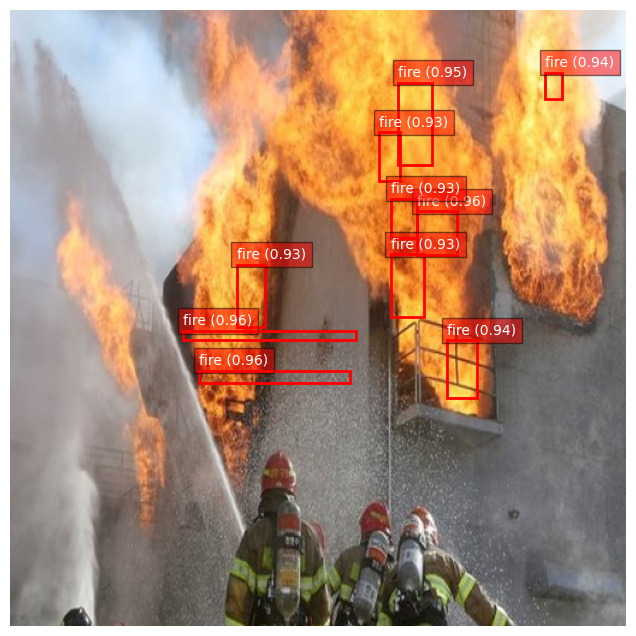

In [156]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import tensorflow as tf

VOC_CLASSES = ["fire"]

# 시각화 함수
def visualize_prediction(image, boxes, classes, scores, threshold=0.3, top_k=10):
        # confidence 기준 상위 top_k 개만 추출
    scores = np.array(scores)
    top_indices = np.argsort(scores)[-top_k:][::-1]

    boxes = np.array(boxes)[top_indices]
    classes = np.array(classes)[top_indices]
    scores = scores[top_indices]
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    for box, cls, score in zip(boxes, classes, scores):
        if score < threshold:
            continue
        
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        class_name = VOC_CLASSES[int(cls)]
        ax.text(
            x1, y1 - 5,
            f"{class_name} ({score:.2f})",
            fontsize=10,
            color="white",
            bbox=dict(facecolor="red", alpha=0.5)
        )

    plt.axis("off")
    plt.show()

# 이미지 불러오기 및 전처리
image_path = '/home/govlept1004/jupyter_home/TF2_Object_Detection/test_images/fire.jpg'
image = Image.open(image_path).resize((512, 512))
image_np = np.array(image)

# 모델 입력용 전처리 (정규화 + 배치 차원 추가)
input_image = image_np / 255.0
input_image = np.expand_dims(input_image, axis=0)  # (1, 512, 512, 3)

# 예측
y_pred = model.predict(input_image)

# 결과 추출 (한 장이니까 [0]만 써도 됨)
boxes = y_pred["boxes"][0]
classes = y_pred["classes"][0]
scores = y_pred["confidence"][0]

# 시각화
visualize_prediction(image_np, boxes, classes, scores, threshold=0.7)

